<a href="https://colab.research.google.com/github/ViniMiranda06/PISI3---Adotai/blob/main-eda/PISI3_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1 - Importações e Configurações

(Rodar apenas uma vez! para ter a base inicial para os dashboards.)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
import shap

# Configurações de exibição
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


# 2 - Carregamento dos Dados

(Baixa e carrega o dataset.)

In [4]:
def carregar_dados():
    arquivo_local = 'aac_intakes_outcomes.csv'
    if os.path.exists(arquivo_local):
        print(f"Carregando arquivo local: {arquivo_local}")
        return pd.read_csv(arquivo_local)

    try:
        import kagglehub
        print("Baixando dados do Kaggle...")
        path = kagglehub.dataset_download("aaronschlegel/austin-animal-center-shelter-intakes-and-outcomes")
        df = pd.read_csv(os.path.join(path, "aac_intakes_outcomes.csv"))
        print("Dados baixados com sucesso!")
        return df
    except Exception as e:
        print(f"Erro ao baixar: {e}")
        return None

df = carregar_dados()

if df is not None:
    print(f"\nDataset carregado! Shape: {df.shape}")
else:
    print("Faça o upload manual do arquivo 'aac_intakes_outcomes.csv' no Colab.")

Baixando dados do Kaggle...
Using Colab cache for faster access to the 'austin-animal-center-shelter-intakes-and-outcomes' dataset.
Dados baixados com sucesso!

Dataset carregado! Shape: (79672, 41)


# 3 - Análise Exploratória (EDA)

(Célula dedicada à análise exploratória e parte gráfica da pesquisa.)


--- Informações Gerais ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79672 entries, 0 to 79671
Data columns (total 41 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   age_upon_outcome            79672 non-null  object 
 1   animal_id_outcome           79672 non-null  object 
 2   date_of_birth               79672 non-null  object 
 3   outcome_subtype             36348 non-null  object 
 4   outcome_type                79662 non-null  object 
 5   sex_upon_outcome            79671 non-null  object 
 6   age_upon_outcome_(days)     79672 non-null  int64  
 7   age_upon_outcome_(years)    79672 non-null  float64
 8   age_upon_outcome_age_group  79672 non-null  object 
 9   outcome_datetime            79672 non-null  object 
 10  outcome_month               79672 non-null  int64  
 11  outcome_year                79672 non-null  int64  
 12  outcome_monthyear           79672 non-null  object 
 13  outc

,age_upon_outcome_(days),age_upon_outcome_(years),outcome_month,outcome_year,outcome_hour,outcome_number,dob_year,dob_month,count,age_upon_intake_(days),age_upon_intake_(years),intake_month,intake_year,intake_hour,intake_number,time_in_shelter_days
count,79672.000000,79672.000000,79672.000000,79672.000000,79672.000000,79672.000000,79672.000000,79672.000000,79672.0,79672.000000,79672.000000,79672.000000,79672.000000,79672.000000,79672.000000,79672.000000
mean,782.046127,2.142592,6.655425,2015.472563,14.297306,1.126820,2013.254870,6.310310,1.0,769.341701,2.107785,6.584032,2015.436101,13.487022,1.126820,16.757116
std,1058.528519,2.900078,3.414284,1.305944,3.774317,0.456057,3.216517,3.289077,0.0,1056.009040,2.893175,3.366579,1.303157,3.121173,0.456057,41.679359
min,0.000000,0.000000,1.000000,2013.000000,0.000000,1.000000,1991.000000,1.000000,1.0,0.000000,0.000000,1.000000,2013.000000,0.000000,1.000000,0.000000
25%,90.000000,0.246575,4.000000,2014.000000,12.000000,1.000000,2012.000000,4.000000,1.0,60.000000,0.164384,4.000000,2014.000000,11.000000,1.000000,1.102083
50%,365.000000,1.000000,7.000000,2015.000000,15.000000,1.000000,2014.000000,6.000000,1.0,365.000000,1.000000,7.000000,2015.000000,13.000000,1.000000,4.987153
75%,1095.000000,3.000000,10.000000,2017.000000,17.000000,1.000000,2015.000000,9.000000,1.0,1095.000000,3.000000,10.000000,2017.000000,16.000000,1.000000,13.610764
max,9125.000000,25.000000,12.000000,2018.000000,23.000000,13.000000,2018.000000,12.000000,1.0,9125.000000,25.000000,12.000000,2018.000000,23.000000,13.000000,1606.194444



--- Estatísticas Descritivas (Categóricas) ---


,age_upon_outcome,animal_id_outcome,date_of_birth,outcome_subtype,outcome_type,sex_upon_outcome,age_upon_outcome_age_group,outcome_datetime,outcome_monthyear,outcome_weekday,dob_monthyear,age_upon_intake,animal_id_intake,animal_type,breed,color,found_location,intake_condition,intake_type,sex_upon_intake,age_upon_intake_age_group,intake_datetime,intake_monthyear,intake_weekday,time_in_shelter
count,79672,79672,79672,36348,79662,79671,79672,79672,79672,79672,79672,79672,79672,79672,79672,79672,79672,79672,79672,79671,79672,79672,79672,79672,79672
unique,46,71961,5923,19,9,5,10,65686,55,7,55,46,71961,4,2155,529,36576,8,5,5,10,56747,54,7,29319
top,1 year,A721033,2014-05-05 00:00:00,Partner,Adoption,Neutered Male,"(-0.025, 2.5]",2016-04-18 00:00:00,2014-07,Saturday,2014-07,1 year,A721033,Dog,Domestic Shorthair Mix,Black/White,Austin (TX),Normal,Stray,Intact Male,"(-0.025, 2.5]",2016-09-23 12:00:00,2015-06,Saturday,0 days 00:17:00.000000000
freq,14750,13,112,19840,33594,28293,59412,39,2072,12848,2072,14580,13,45366,23423,8270,14311,70056,55935,25317,59593,64,2188,12037,77


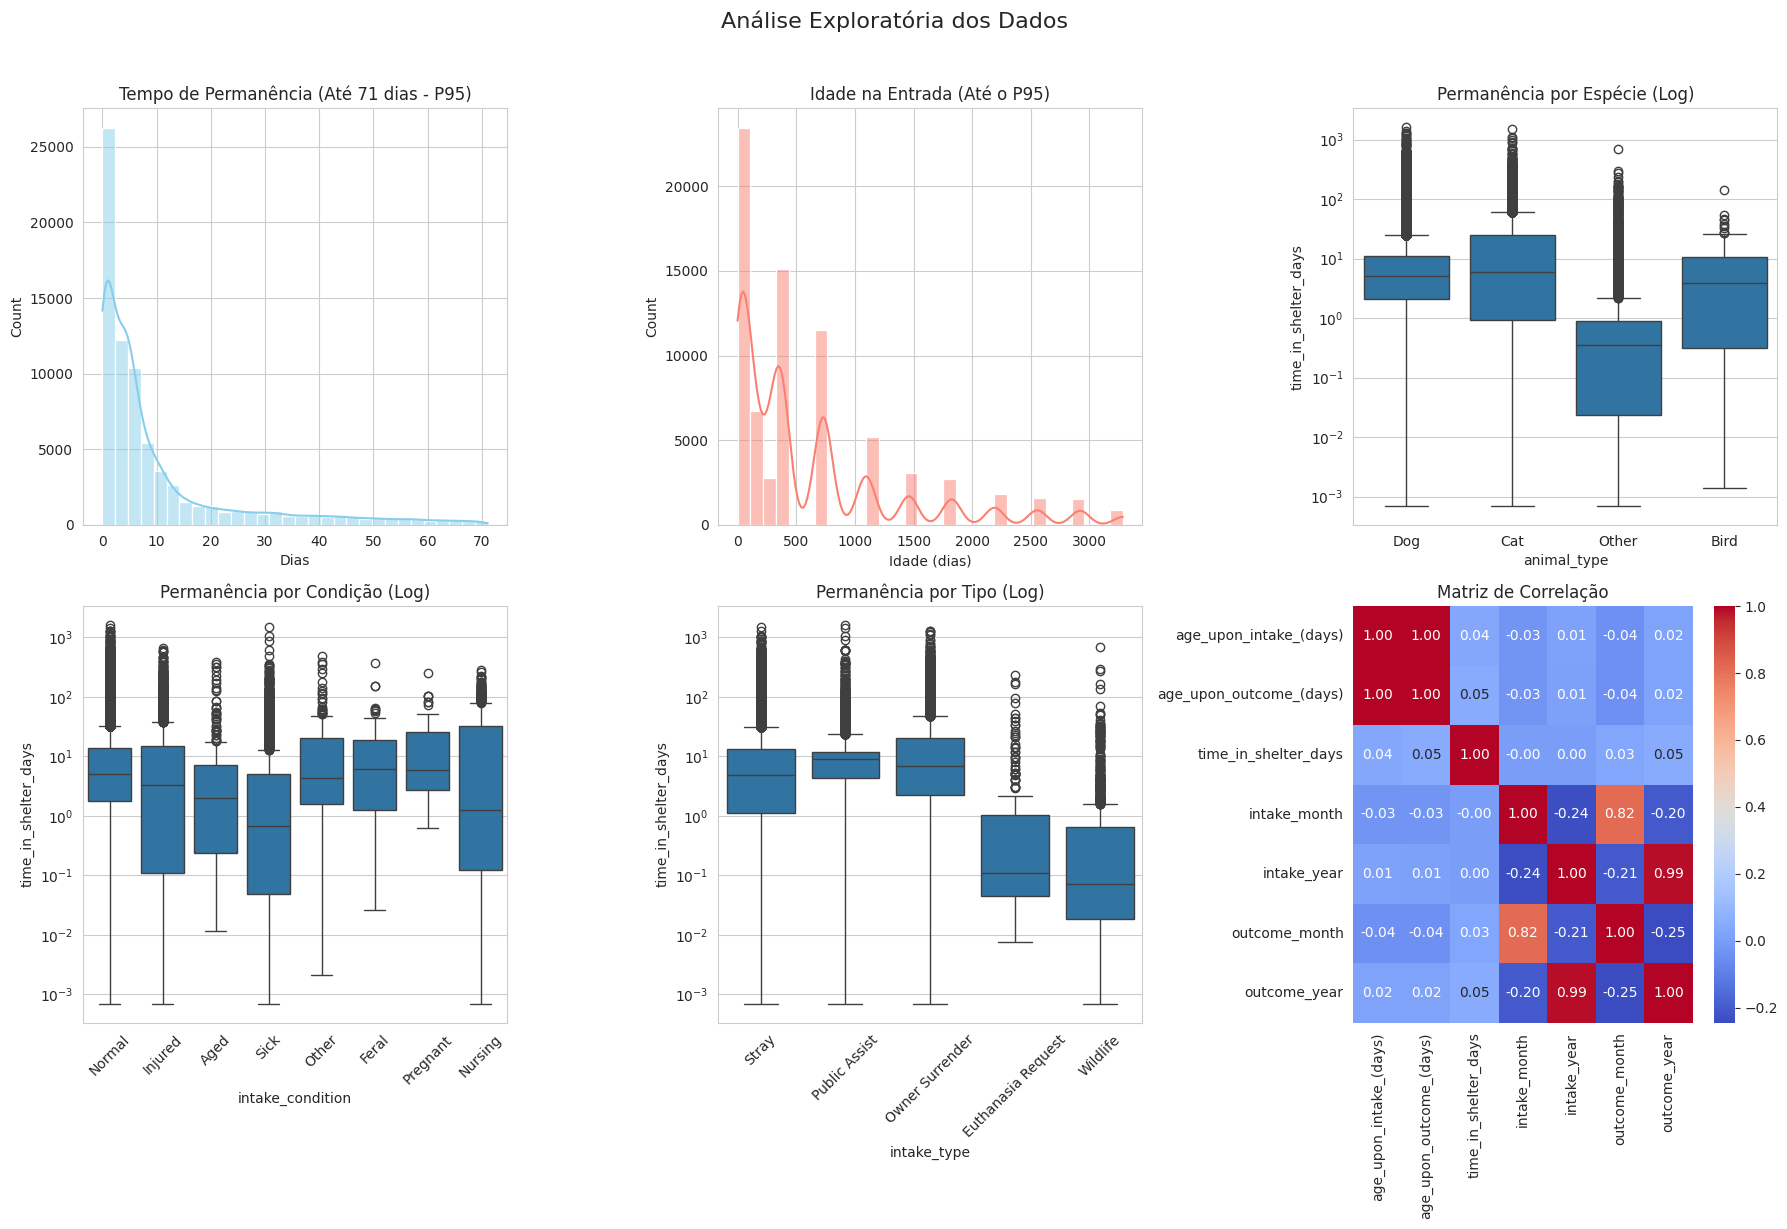

In [5]:
# =============================================================================
# BLOCO 3: ANÁLISE EXPLORATÓRIA (VISÃO GERAL E GRÁFICOS)
# =============================================================================

# Informações gerais do dataset
print("--- Informações Gerais ---")
df.info()

print("\n--- Estatísticas Descritivas (Numéricas) ---")
display(df.describe())

print("\n--- Estatísticas Descritivas (Categóricas) ---")
display(df.describe(include=['object', 'category']))

# Função para categorizar os dias
def categorizar_stay(dias):
    # Tratando também valores negativos na categorização
    if pd.isna(dias) or dias < 0:
        return 'Desconhecido'
    elif dias <= 14:
        return 'Curta'
    elif dias <= 45:
        return 'Média'
    else:
        return 'Longa'

df['stay_category'] = df['time_in_shelter_days'].apply(categorizar_stay)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Análise Exploratória dos Dados', fontsize=16, y=1.02)

# 1. Correção do Tempo de Permanência
limite_superior = df['time_in_shelter_days'].quantile(0.95)
dados_permanencia = df[(df['time_in_shelter_days'] >= 0) & (df['time_in_shelter_days'] <= limite_superior)]['time_in_shelter_days']

sns.histplot(dados_permanencia, kde=True, bins=30, ax=axes[0,0], color='skyblue')
axes[0,0].set_title(f'Tempo de Permanência (Até {int(limite_superior)} dias - P95)')
axes[0,0].set_xlabel('Dias')

# 2. Distribuição da Idade na Entrada
limite_idade = df['age_upon_intake_(days)'].quantile(0.95)
dados_idade = df[(df['age_upon_intake_(days)'] >= 0) & (df['age_upon_intake_(days)'] <= limite_idade)]['age_upon_intake_(days)']

sns.histplot(dados_idade, kde=True, bins=30, ax=axes[0,1], color='salmon')
axes[0,1].set_title(f'Idade na Entrada (Até o P95)')
axes[0,1].set_xlabel('Idade (dias)')

# 3. Permanência por Espécie
df_valido = df[df['time_in_shelter_days'] > 0]

sns.boxplot(x='animal_type', y='time_in_shelter_days', data=df_valido, ax=axes[0,2])
axes[0,2].set_yscale('log')
axes[0,2].set_title('Permanência por Espécie (Log)')

# 4. Permanência por Condição
sns.boxplot(x='intake_condition', y='time_in_shelter_days', data=df_valido, ax=axes[1,0])
axes[1,0].set_yscale('log')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].set_title('Permanência por Condição (Log)')

# 5. Permanência por Tipo de Entrada
sns.boxplot(x='intake_type', y='time_in_shelter_days', data=df_valido, ax=axes[1,1])
axes[1,1].set_yscale('log')
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].set_title('Permanência por Tipo (Log)')

# 6. Correlação
numeric_cols = [
    'age_upon_intake_(days)', 'age_upon_outcome_(days)',
    'time_in_shelter_days', 'intake_month', 'intake_year',
    'outcome_month', 'outcome_year'
]

sns.heatmap(df[numeric_cols].dropna().corr(), annot=True, cmap='coolwarm', fmt='.2f', ax=axes[1,2])
axes[1,2].set_title('Matriz de Correlação')

plt.tight_layout()
plt.show()

In [6]:
# =============================================================================
# BLOCO DE AUDITORIA: INVESTIGANDO TEMPOS DE PERMANÊNCIA EXTREMAMENTE CURTOS
# =============================================================================

print("--- 1. Verificando valores Negativos ou Zerados ---")
negativos = df[df['time_in_shelter_days'] < 0]
zerados = df[df['time_in_shelter_days'] == 0]
print(f"Registros com permanência NEGATIVA (< 0 dias): {len(negativos)}")
print(f"Registros com permanência ZERADA (Exatamente 0 dias): {len(zerados)}")

print("\n--- 2. Verificando tempos menores que 1 hora (< 0.0416 dias) ---")
# 1 hora = 1/24 de um dia (~0.0416)
curtos = df[(df['time_in_shelter_days'] > 0) & (df['time_in_shelter_days'] <= (1/24))]
print(f"Animais que ficaram de 1 segundo a 60 minutos: {len(curtos)}")

print("\n--- 3. O que acontece com esses animais 'relâmpago'? (Destino) ---")
if len(curtos) > 0:
    print(curtos['outcome_type'].value_counts())

print("\n--- 4. Como eles entraram no abrigo? (Tipo de Entrada) ---")
if len(curtos) > 0:
    print(curtos['intake_type'].value_counts())

print("\n--- 5. Verificando a consistência do cálculo (Data Saída - Data Entrada) ---")
# Se as colunas originais de data estiverem disponíveis no dataset carregado:
try:
    df['intake_dt'] = pd.to_datetime(df['intake_datetime'])
    df['outcome_dt'] = pd.to_datetime(df['outcome_datetime'])
    df['calc_diff_days'] = (df['outcome_dt'] - df['intake_dt']).dt.total_seconds() / 86400

    # Compara a variável do dataset com o nosso recálculo
    divergentes = df[abs(df['time_in_shelter_days'] - df['calc_diff_days']) > 0.1]
    print(f"Registros onde o cálculo de dias não bate com as datas: {len(divergentes)}")

    if len(divergentes) > 0:
        display(divergentes[['intake_datetime', 'outcome_datetime', 'time_in_shelter_days', 'calc_diff_days']].head())
except KeyError:
    print("As colunas 'intake_datetime' e 'outcome_datetime' não estão disponíveis para recalcular.")

--- 1. Verificando valores Negativos ou Zerados ---
Registros com permanência NEGATIVA (< 0 dias): 0
Registros com permanência ZERADA (Exatamente 0 dias): 1

--- 2. Verificando tempos menores que 1 hora (< 0.0416 dias) ---
Animais que ficaram de 1 segundo a 60 minutos: 3441

--- 3. O que acontece com esses animais 'relâmpago'? (Destino) ---
outcome_type
Euthanasia         2175
Transfer            712
Return to Owner     456
Disposal             55
Died                 32
Adoption             10
Missing               1
Name: count, dtype: int64

--- 4. Como eles entraram no abrigo? (Tipo de Entrada) ---
intake_type
Stray                 1682
Wildlife              1481
Owner Surrender        142
Public Assist           80
Euthanasia Request      56
Name: count, dtype: int64

--- 5. Verificando a consistência do cálculo (Data Saída - Data Entrada) ---
Registros onde o cálculo de dias não bate com as datas: 0


# 4 - Pré-processamento e Divisão dos Dados
(Tratamento de nulos, encoding, normalização e train_test_split.)


In [7]:
features = ['animal_type', 'age_upon_intake_(days)', 'sex_upon_intake',
            'intake_condition', 'intake_type', 'intake_month',
            'intake_year', 'intake_weekday', 'intake_hour']

X = df[features].copy()
y = df['stay_category'].copy()

# Tratamento de nulos
valid_mask = ~y.isna()
X, y = X[valid_mask], y[valid_mask]
X['age_upon_intake_(days)'] = X['age_upon_intake_(days)'].fillna(X['age_upon_intake_(days)'].median())
X['intake_weekday'] = X['intake_weekday'].fillna('Unknown')
X['intake_hour'] = X['intake_hour'].fillna(X['intake_hour'].median())

# Encoding e Scaling
categorical_cols = ['animal_type', 'sex_upon_intake', 'intake_condition', 'intake_type', 'intake_weekday']
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

numeric_features = ['age_upon_intake_(days)', 'intake_month', 'intake_year', 'intake_hour']
scaler = StandardScaler()
X_encoded[numeric_features] = scaler.fit_transform(X_encoded[numeric_features])

# Divisão
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)
print(f"Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras")

Treino: 63737 amostras | Teste: 15935 amostras


# 5 - Clusterização (K-Means)

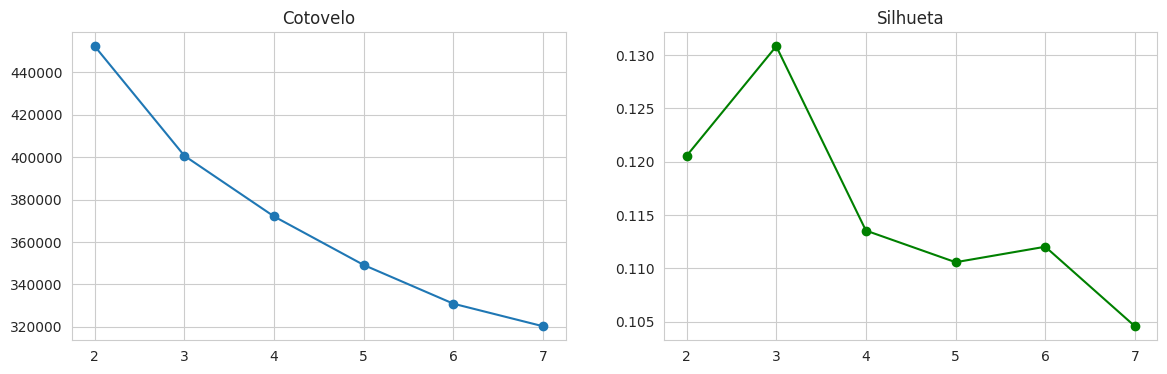

Melhor K encontrado: 3


In [8]:
# Limitando n_init para acelerar
inertias, silhouettes, K_range = [], [], range(2, 8) # Reduzi o range máximo para 8 para ser mais rápido

# Usamos uma amostra menor para calcular silhueta se o dataset for gigante
sample_size = min(10000, X_encoded.shape[0])
X_sample = X_encoded.sample(n=sample_size, random_state=42)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=5)
    kmeans.fit(X_encoded)
    inertias.append(kmeans.inertia_)
    # Silhueta calculada apenas na amostra para não travar
    silhouettes.append(silhouette_score(X_sample, kmeans.predict(X_sample)))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(K_range, inertias, marker='o'); axes[0].set_title('Cotovelo')
axes[1].plot(K_range, silhouettes, marker='o', color='green'); axes[1].set_title('Silhueta')
plt.show()

best_k = K_range[np.argmax(silhouettes)]
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df.loc[valid_mask, 'cluster'] = kmeans.fit_predict(X_encoded)
print(f"Melhor K encontrado: {best_k}")


# 6 - Treinamento dos Modelos Clássicos
(Smote isolado para termos uma visão dos resultados originais + prevenção de perda de memória.)

In [9]:
models = {
    'Random Forest': RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1),
    'Logistic Regression': LogisticRegression(max_iter=500, random_state=42, n_jobs=-1),
    'KNN': KNeighborsClassifier(n_jobs=-1)
    # 'SVM': SVC(probability=True, random_state=42) # <- DESCOMENTE POR SUA CONTA E RISCO
}

def extrair_metricas(y_true, y_pred, classes):
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    return {
        'Macro avg F1': report['macro avg']['f1-score'],
        'Accuracy': accuracy_score(y_true, y_pred)
    }

classes = ['Curta', 'Média', 'Longa']
results_no_smote = []

for name, model in models.items():
    print(f"Treinando {name}...")
    model.fit(X_train, y_train)

    metrics = extrair_metricas(y_test, model.predict(X_test), classes)
    results_no_smote.append({
        'Modelo': name, 'Balanceamento': 'Sem SMOTE',
        'Test Accuracy': metrics['Accuracy'], 'Test Macro F1': metrics['Macro avg F1']
    })

print("Treinamento sem SMOTE concluído!")
pd.DataFrame(results_no_smote)

Treinando Random Forest...
Treinando Logistic Regression...
Treinando KNN...
Treinamento sem SMOTE concluído!


,Modelo,Balanceamento,Test Accuracy,Test Macro F1
0,Random Forest,Sem SMOTE,0.773768,0.529654
1,Logistic Regression,Sem SMOTE,0.753248,0.286420
2,KNN,Sem SMOTE,0.746533,0.444413


# 7 - SMOTE e Retreinamento

(Balanceamento, aplicação do SMOTE e retreinamento.)

In [10]:
print("Aplicando SMOTE...")
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

results_smote = []
for name, model in models.items():
    print(f"Treinando {name} com SMOTE...")
    model.fit(X_train_res, y_train_res)

    metrics = extrair_metricas(y_test, model.predict(X_test), classes)
    results_smote.append({
        'Modelo': name, 'Balanceamento': 'Com SMOTE',
        'Test Accuracy': metrics['Accuracy'], 'Test Macro F1': metrics['Macro avg F1']
    })

print("Treinamento com SMOTE concluído!")
pd.DataFrame(results_smote)

Aplicando SMOTE...
Treinando Random Forest com SMOTE...
Treinando Logistic Regression com SMOTE...
Treinando KNN com SMOTE...
Treinamento com SMOTE concluído!


,Modelo,Balanceamento,Test Accuracy,Test Macro F1
0,Random Forest,Com SMOTE,0.748792,0.527575
1,Logistic Regression,Com SMOTE,0.529338,0.388797
2,KNN,Com SMOTE,0.577471,0.441384


# 8 - Explicabilidade (SHAP)
(Explicabilidade do Random Forest.)

Gerando SHAP Values para Random Forest...


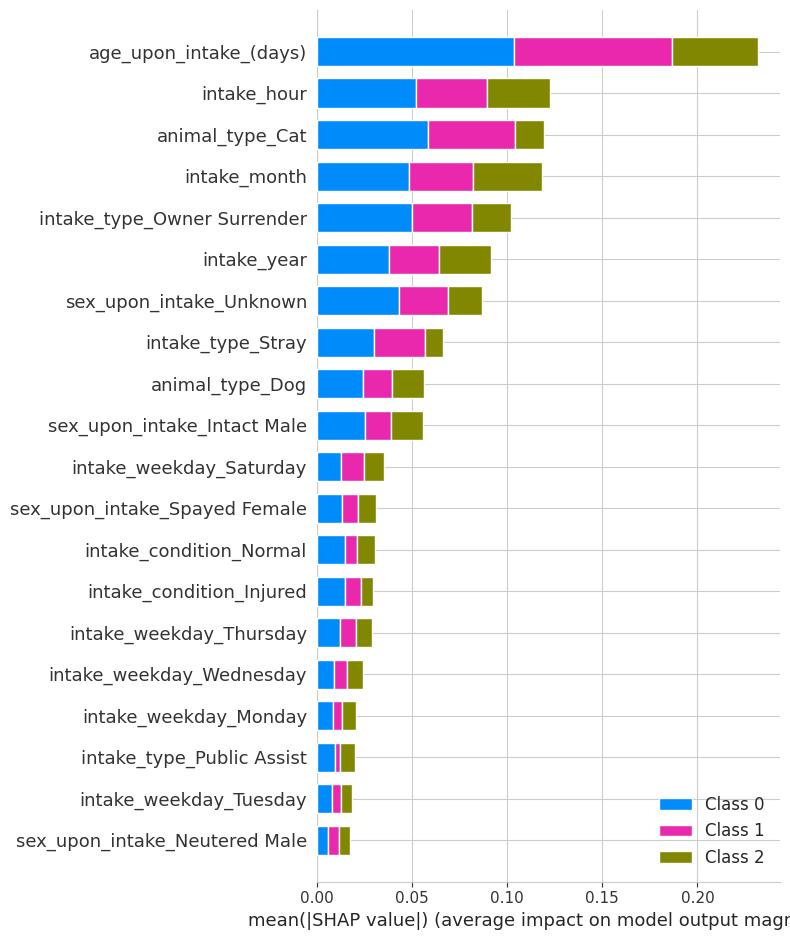

In [11]:
print("Gerando SHAP Values para Random Forest...")
rf_model = models['Random Forest']

# Dica: Calcular SHAP no dataset inteiro de teste é muito lento.
# Pegamos uma amostra representativa (ex: 500 a 1000 linhas) para desenhar os gráficos.
X_test_sample = shap.sample(X_test, 50)

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_sample)

# O formato do SHAP muda dependendo da versão (lista de arrays para multiclasse).
# Acessamos o índice [1] como exemplo (classe 'Média' ou dependendo da ordem)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_sample, plot_type='bar')
plt.show()